# Vein segmentation → skeleton → needle target (research prototype)
Pipeline: **U-Net mask → clean → skeleton → branch points → best straight/thick segment → target point**.

**Before you run:** Notebook settings → Accelerator = GPU (T4 x2 / P100), Internet = **On** (needed to download pretrained encoder weights).

**Not for use on real patients.** This is a research/education prototype. NIR imaging is 2-D, so the target is a *surface* position only (no depth).

In [56]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.9 MB/s eta 0:00:00


## 1. Post-processing module (skeleton, branch points, target selection)

In [59]:
%%writefile vein_postprocess.py
"""
Vein post-processing: probability map -> clean mask -> skeleton -> junctions
-> best straight/thick segment -> needle target point (+ direction).
Pure numpy / scipy / scikit-image / OpenCV (no deep-learning dependency).
"""
import cv2
import numpy as np
from dataclasses import dataclass
from scipy import ndimage as ndi
from skimage.morphology import skeletonize

K8 = np.ones((3, 3), int)
K8[1, 1] = 0


@dataclass
class Target:
    x: int
    y: int
    width_px: float          # local vein diameter (2 x distance transform)
    direction: np.ndarray    # unit vector along the vein (dx, dy)
    dist_to_junction_px: float
    score: float


def clean_mask(prob, thr=0.5, min_area=80):
    m = (prob > thr).astype(np.uint8)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    keep = np.zeros(n, bool)
    keep[1:] = stats[1:, cv2.CC_STAT_AREA] >= min_area          # drop tiny blobs (noise)
    m = keep[lab].astype(np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    return m.astype(bool)


def _neighbours(skel):
    return ndi.convolve(skel.astype(int), K8, mode="constant") * skel


def prune_spurs(skel, spur_len=10, passes=2):
    """Remove short side-branches (skeleton 'hairs') that hang off a junction."""
    skel = skel.copy()
    for _ in range(passes):
        nb = _neighbours(skel)
        junc = skel & (nb >= 3)
        zone = cv2.dilate(junc.astype(np.uint8), np.ones((3, 3), np.uint8)).astype(bool)
        branches = skel & ~zone
        lab, n = ndi.label(branches, structure=np.ones((3, 3)))
        endpoints = skel & (nb == 1)
        zone_touch = cv2.dilate(zone.astype(np.uint8), np.ones((3, 3), np.uint8)).astype(bool)
        for i in range(1, n + 1):
            comp = lab == i
            if comp.sum() < spur_len and (comp & endpoints).any() and (comp & zone_touch).any():
                skel[comp] = False
        skel = skeletonize(skel)
    return skel


def analyse(prob, thr=0.5, min_area=80, spur_len=10, junction_pad=6):
    mask = clean_mask(prob, thr, min_area)
    dt = ndi.distance_transform_edt(mask)                 # radius at every vein pixel
    skel = prune_spurs(skeletonize(mask), spur_len)
    nb = _neighbours(skel)
    junctions = skel & (nb >= 3)                          # bifurcations / confluences
    endpoints = skel & (nb == 1)
    k = 2 * junction_pad + 1
    jzone = cv2.dilate(junctions.astype(np.uint8), np.ones((k, k), np.uint8)).astype(bool)
    segments, nseg = ndi.label(skel & ~jzone, structure=np.ones((3, 3)))
    dist_to_j = (ndi.distance_transform_edt(~junctions) if junctions.any()
                 else np.full(mask.shape, 1e6))
    return dict(mask=mask, dt=dt, skel=skel, junctions=junctions, endpoints=endpoints,
                segments=segments, nseg=nseg, dist_to_j=dist_to_j)


def _direction(pts, cy, cx, r=12):
    d = np.hypot(pts[:, 0] - cy, pts[:, 1] - cx)
    p = pts[d <= r].astype(float)
    if len(p) < 3:
        return np.array([1.0, 0.0])
    p -= p.mean(0)
    _, _, vt = np.linalg.svd(p, full_matrices=False)
    v = vt[0]                                             # (dy, dx)
    return np.array([v[1], v[0]])                         # -> (dx, dy)


def pick_target(a, min_len=25, min_width=4.0, safe_junction_px=15, end_margin=8):
    """Choose the best needle target on the best segment.
    score = width * straightness * length factor; pixel = widest point that is
    far from junctions and from the ends of the segment."""
    best = None
    for i in range(1, a["nseg"] + 1):
        ys, xs = np.nonzero(a["segments"] == i)
        L = len(ys)
        if L < min_len:
            continue
        pts = np.stack([ys, xs], 1)
        w = 2 * a["dt"][ys, xs]
        # straightness: 1.0 = straight line, lower = curvy
        s = np.linalg.svd(pts - pts.mean(0), compute_uv=False)
        straight = 1.0 if s[1] < 1e-6 else float(1 - min(s[1] / s[0], 1.0))
        # keep pixels away from junctions and from segment ends
        far_j = a["dist_to_j"][ys, xs] >= safe_junction_px
        ends = a["endpoints"][ys, xs]
        if ends.any():
            ey, ex = ys[ends], xs[ends]
            far_e = np.min(np.hypot(ys[:, None] - ey[None], xs[:, None] - ex[None]), 1) >= end_margin
        else:
            far_e = np.ones(L, bool)
        # smooth width along the segment to ignore single-pixel noise
        w_s = ndi.uniform_filter1d(w[np.argsort(ys * 10000 + xs)], 5)[np.argsort(np.argsort(ys * 10000 + xs))]
        ok = far_j & far_e & (w_s >= min_width)
        if not ok.any():
            continue
        idx = np.flatnonzero(ok)[np.argmax(w_s[ok])]
        seg_score = float(w_s[idx] * straight * min(L / 60.0, 1.0))
        if best is None or seg_score > best.score:
            best = Target(int(xs[idx]), int(ys[idx]), float(w_s[idx]),
                          _direction(pts, ys[idx], xs[idx]),
                          float(a["dist_to_j"][ys[idx], xs[idx]]), seg_score)
    return best


def draw(img_bgr, a, target, show_junctions=True):
    out = img_bgr.copy()
    out[a["skel"]] = (0, 255, 0)                          # green skeleton
    if show_junctions:
        for y, x in zip(*np.nonzero(a["junctions"])):
            cv2.circle(out, (int(x), int(y)), 3, (0, 165, 255), -1)   # orange = branch point
    if target is not None:
        c = (target.x, target.y)
        cv2.drawMarker(out, c, (0, 0, 255), cv2.MARKER_CROSS, 24, 2)  # red pointer
        tip = (int(c[0] + 30 * target.direction[0]), int(c[1] + 30 * target.direction[1]))
        cv2.arrowedLine(out, c, tip, (255, 0, 0), 1, tipLength=0.3)   # vein axis
        cv2.putText(out, f"TARGET: ({target.x}, {target.y})  w={target.width_px:.1f}px",
                    (c[0] + 12, c[1] - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
    return out


class TargetSmoother:
    """Video use: exponential smoothing + only report when stable."""
    def __init__(self, alpha=0.3, jump_px=25):
        self.alpha, self.jump, self.p = alpha, jump_px, None

    def update(self, t):
        if t is None:
            return None if self.p is None else tuple(map(int, self.p))
        q = np.array([t.x, t.y], float)
        if self.p is None or np.linalg.norm(q - self.p) > self.jump:
            self.p = q                                    # re-lock on a new vein
        else:
            self.p = (1 - self.alpha) * self.p + self.alpha * q
        return tuple(map(int, self.p))


Overwriting vein_postprocess.py


## 2. Sanity test WITHOUT a trained model (optional)
Uses your ink-drawn dummy image: blue-ink colour threshold stands in for the network's probability map, so you can check the skeleton / junction / target logic first.

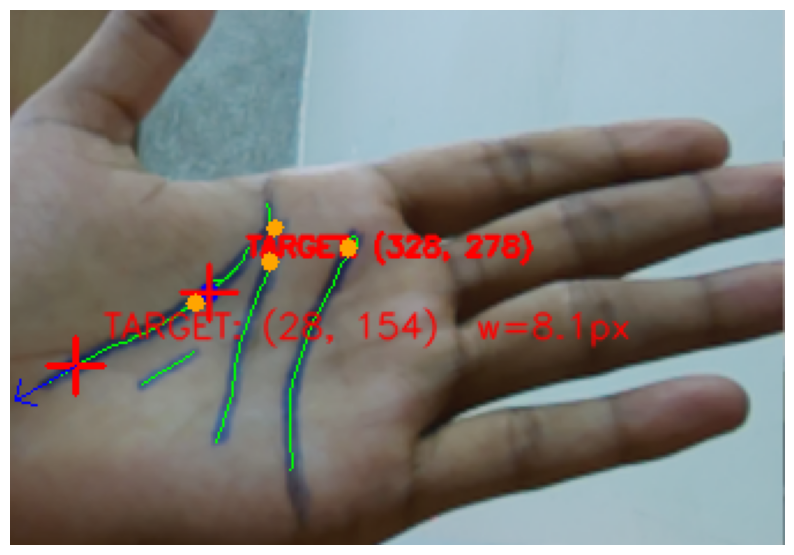

In [61]:
import cv2, numpy as np, matplotlib.pyplot as plt
from vein_postprocess import *

img = cv2.imread("/kaggle/input/datasets/minhaj099/dummy-palm-img/dummy_palm_crop.png")      # <- change [dummy_palm_img_path]
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
prob = cv2.inRange(hsv, (100, 60, 20), (135, 255, 200)).astype(np.float32) / 255
a = analyse(prob, thr=0.5, min_area=30, spur_len=8, junction_pad=4)
t = pick_target(a, min_len=15, min_width=3.0, safe_junction_px=8, end_margin=6)
plt.figure(figsize=(10, 8)); plt.imshow(draw(img, a, t)[..., ::-1]); plt.axis("off"); plt.show()

## 3. Make pixel masks (boxes cannot give a centreline)
Your Roboflow boxes cannot be converted to masks. Options:
* **Fast start:** generate draft masks with a ridge filter (cell below), then correct them by hand in CVAT / Labelme / Roboflow (Polygon or Smart-Polygon).
* Draw each vein as a **polyline with thickness** (CVAT) so thin veins stay continuous.

Folder layout expected below: `<root>/images/*.png` and `<root>/masks/*.png` (vein = 255, background = 0, same file name).

In [70]:
import os, glob, cv2, numpy as np
from skimage.filters import sato

def draft_mask(gray, sigmas=(1.5, 2.5, 3.5), pct=90):
    """Ridge-filter draft of a vein mask from an NIR image. ALWAYS review/correct by hand."""
    g = cv2.createCLAHE(3.0, (8, 8)).apply(gray)
    g = cv2.GaussianBlur(g, (0, 0), 1.0)
    r = sato(g.astype(np.float32) / 255, sigmas=sigmas, black_ridges=True)   # veins are dark in NIR
    return ((r > np.percentile(r, pct)) * 255).astype(np.uint8)

SRC, DST = "/kaggle/input/datasets/minhaj099/vein-yolov11/Vein.v1i.yolov11/train/images", "/kaggle/working/masks_draft"      # <- change
os.makedirs(DST, exist_ok=True)
for p in glob.glob(f"{SRC}/*.*"):
    g = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if g is not None:
        cv2.imwrite(f"{DST}/{os.path.splitext(os.path.basename(p))[0]}.png", draft_mask(g))

train: 83 pairs | polygon labels: 83 | box labels (pseudo-masks): 0 | skipped: 0
valid: 21 pairs | polygon labels: 21 | box labels (pseudo-masks): 0 | skipped: 0
persons in both train and valid: ['person_001', 'person_002', 'person_003', 'person_008', 'person_009', 'person_011', 'person_012', 'person_013']


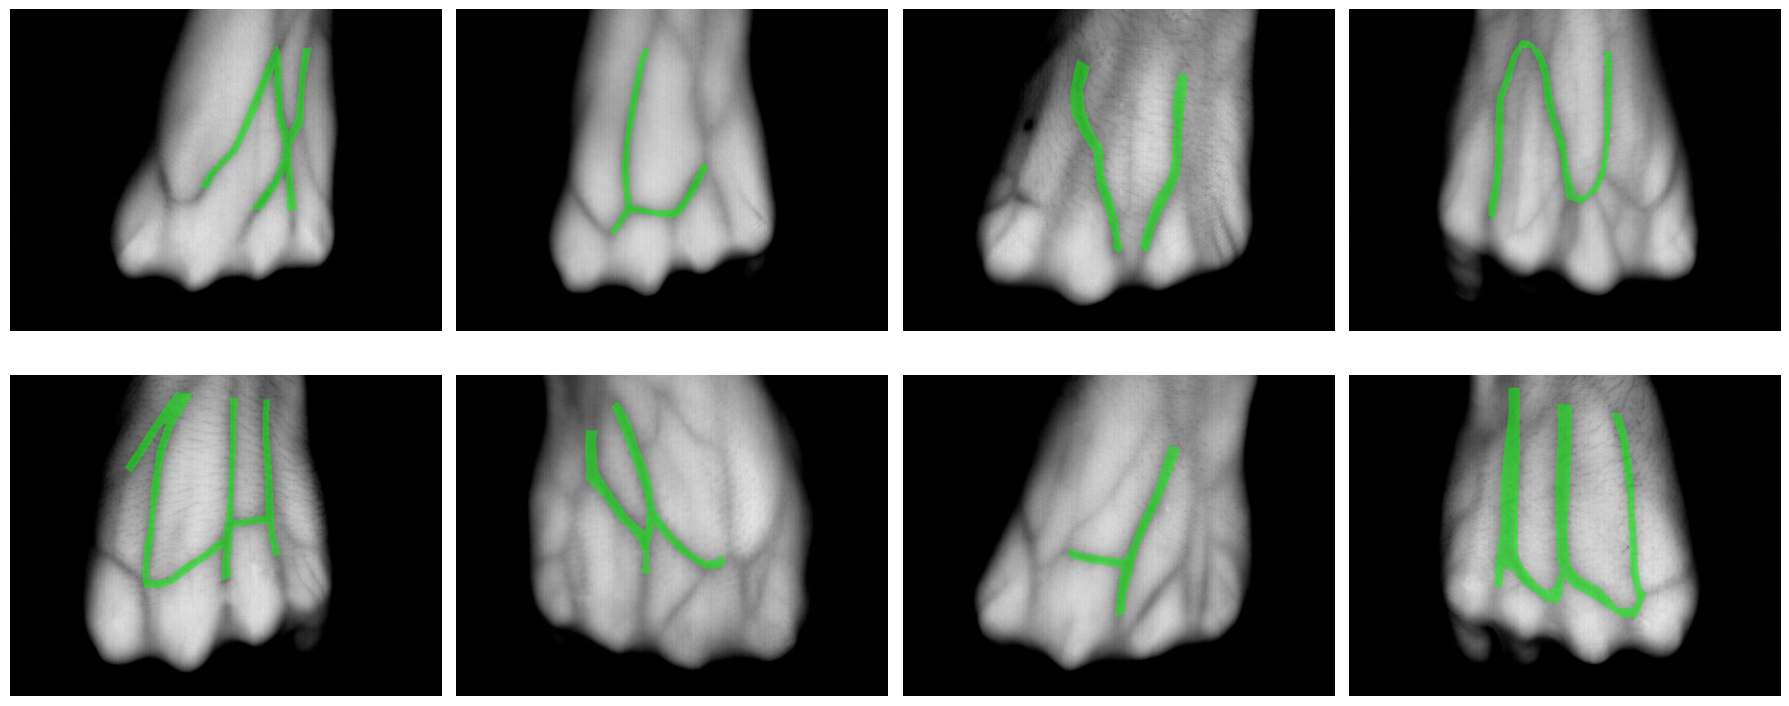

In [76]:
import os, glob, cv2, numpy as np
from skimage.filters import sato, apply_hysteresis_threshold
import matplotlib.pyplot as plt

DS  = "/kaggle/input/datasets/minhaj099/vein-yolov11/Vein.v1i.yolov11"   # folder with train/ and valid/
OUT = "/kaggle/working/masks"                                            # masks are written here (input is read-only)
BLACK_RIDGES = True      # True: veins are DARK in your NIR images. If the preview looks inverted, set False.
clahe = cv2.createCLAHE(3.0, (8, 8))

def read_yolo(path, w, h):
    """Split a YOLO .txt into boxes (class cx cy w h) and polygons (class x1 y1 x2 y2 ...)."""
    boxes, polys = [], []
    for line in open(path):
        v = line.split()
        if len(v) < 5:
            continue
        vals = list(map(float, v[1:]))
        if len(vals) == 4:                                   # bounding box
            cx, cy, bw, bh = vals
            x1, y1 = max(int((cx - bw / 2) * w), 0), max(int((cy - bh / 2) * h), 0)
            x2, y2 = min(int((cx + bw / 2) * w), w), min(int((cy + bh / 2) * h), h)
            boxes.append((x1, y1, x2, y2))
        else:                                                # polygon -> real mask
            polys.append((np.array(vals).reshape(-1, 2) * [w, h]).astype(np.int32))
    return boxes, polys

def ridge_mask_in_boxes(gray, boxes):
    """Pseudo-mask: ridge filter (Sato) restricted to the labelled boxes, hysteresis-thresholded."""
    g = cv2.GaussianBlur(clahe.apply(gray), (0, 0), 1.0)
    r = sato(g.astype(np.float32) / 255, sigmas=(1.5, 2.5, 3.5), black_ridges=BLACK_RIDGES)
    roi = np.zeros(gray.shape, bool)
    for x1, y1, x2, y2 in boxes:
        roi[y1:y2, x1:x2] = True
    if not roi.any():
        return np.zeros(gray.shape, np.uint8)
    rmax = np.percentile(r[roi], 99.5)                       # robust maximum of the ridge response
    lo, hi = 0.15 * rmax, 0.35 * rmax                        # relative thresholds: weak texture is ignored
    m = (apply_hysteresis_threshold(r, lo, hi) & roi).astype(np.uint8)
    n, lab, st, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    keep = np.zeros(n, bool)
    ext = np.maximum(st[1:, cv2.CC_STAT_WIDTH], st[1:, cv2.CC_STAT_HEIGHT])
    keep[1:] = (st[1:, cv2.CC_STAT_AREA] >= 40) & (ext >= 25)   # drop short specks: veins are long
    return (keep[lab] * 255).astype(np.uint8)

def convert_split(split):
    os.makedirs(f"{OUT}/{split}", exist_ok=True)
    pairs, n_poly, n_box, n_empty = [], 0, 0, 0
    for ip in sorted(glob.glob(f"{DS}/{split}/images/*.*")):
        stem = os.path.splitext(os.path.basename(ip))[0]
        lp = f"{DS}/{split}/labels/{stem}.txt"
        gray = cv2.imread(ip, cv2.IMREAD_GRAYSCALE)
        if gray is None or not os.path.exists(lp):
            n_empty += 1; continue
        h, w = gray.shape
        boxes, polys = read_yolo(lp, w, h)
        if polys:                                            # real pixel-level annotation
            mask = np.zeros((h, w), np.uint8)
            cv2.fillPoly(mask, polys, 255); n_poly += 1
        elif boxes:                                          # only boxes -> pseudo-mask
            mask = ridge_mask_in_boxes(gray, boxes); n_box += 1
        else:
            n_empty += 1; continue
        mp = f"{OUT}/{split}/{stem}.png"
        cv2.imwrite(mp, mask)
        pairs.append((ip, mp))
    print(f"{split}: {len(pairs)} pairs | polygon labels: {n_poly} | box labels (pseudo-masks): {n_box} | skipped: {n_empty}")
    return pairs

train_pairs = convert_split("train")
val_pairs   = convert_split("valid")

# Leakage check: the same person must not appear in both train and valid
pid = lambda p: os.path.basename(p).split("_db")[0]          # e.g. "person_001"
overlap = {pid(p) for p, _ in train_pairs} & {pid(p) for p, _ in val_pairs}
print("persons in both train and valid:", sorted(overlap) if overlap else "none (good)")

# ALWAYS look at the masks before training
fig, ax = plt.subplots(2, 4, figsize=(18, 8))
for a_ in ax.ravel():
    a_.axis("off")
for a_, (ip, mp) in zip(ax.ravel(), train_pairs[::max(1, len(train_pairs) // 8)][:8]):
    im = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
    m = cv2.imread(mp, 0) > 127
    im[m] = (0.5 * im[m] + 0.5 * np.array([0, 255, 0])).astype(np.uint8)
    a_.imshow(im)
plt.tight_layout(); plt.show()

## 4. Dataset, augmentation, model

In [75]:
import os, glob, random, cv2, numpy as np, torch, torch.nn as nn
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

ROOT = "/kaggle/input/datasets/minhaj099/vein-yolov11/Vein.v1i.yolov11/train"        # <- change: contains images/ and masks/
SIZE = 512                                       # keep high: thin veins vanish at low resolution
device = "cuda" if torch.cuda.is_available() else "cpu"

imgs = sorted(glob.glob(f"{ROOT}/images/*.*"))
pairs = []
for p in imgs:
    m = f"{ROOT}/labels/{os.path.splitext(os.path.basename(p))[0]}.png"
    if os.path.exists(m):
        pairs.append((p, m))
print(len(imgs), "images found,", len(pairs), "have a matching mask")
if not pairs:
    print("image examples:", [os.path.basename(p) for p in imgs[:3]])
    print("mask examples: ", sorted(os.listdir(f"{ROOT}/labels"))[:3])
    raise FileNotFoundError("No image/mask pairs matched: each mask must have the same name as its image, saved as .png")

def group_id(path):
    # Roboflow augmented copies share the text before ".rf." -> keep them in the same split
    return os.path.basename(path).split(".rf.")[0]

groups = sorted({group_id(p) for p, _ in pairs})
random.seed(0)
if len(groups) >= 5:
    random.shuffle(groups)
    val_groups = set(groups[: max(1, int(0.2 * len(groups)))])
    train_pairs = [x for x in pairs if group_id(x[0]) not in val_groups]
    val_pairs   = [x for x in pairs if group_id(x[0]) in val_groups]
else:
    print("WARNING: too few groups, using a random per-file split (frames of the same hand can leak between train and val)")
    random.shuffle(pairs)
    k = max(1, int(0.2 * len(pairs)))
    val_pairs, train_pairs = pairs[:k], pairs[k:]
print(len(train_pairs), "train /", len(val_pairs), "val")

norm = A.Normalize()
train_tf = A.Compose([A.Resize(SIZE, SIZE), A.HorizontalFlip(), A.Rotate(15, border_mode=cv2.BORDER_CONSTANT),
                      A.RandomBrightnessContrast(0.2, 0.2), norm, ToTensorV2()])   # no elastic warps: they break thin veins
val_tf = A.Compose([A.Resize(SIZE, SIZE), norm, ToTensorV2()])
clahe = cv2.createCLAHE(3.0, (8, 8))

def load_gray3(path):
    g = clahe.apply(cv2.imread(path, cv2.IMREAD_GRAYSCALE))
    return cv2.cvtColor(g, cv2.COLOR_GRAY2RGB)

class VeinDS(Dataset):
    def __init__(self, pairs, tf): self.pairs, self.tf = pairs, tf
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        ip, mp = self.pairs[i]
        m = (cv2.imread(mp, 0) > 127).astype(np.float32)
        o = self.tf(image=load_gray3(ip), mask=m)
        return o["image"], o["mask"].unsqueeze(0)

tl = DataLoader(VeinDS(train_pairs, train_tf), batch_size=8, shuffle=True, num_workers=2, drop_last=True)
vl = DataLoader(VeinDS(val_pairs, val_tf), batch_size=8, num_workers=2)

model = smp.Unet("resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(device)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)              # uses both T4s
dice_loss, bce = smp.losses.DiceLoss("binary"), nn.BCEWithLogitsLoss()
loss_fn = lambda p, y: 0.5 * bce(p, y) + 0.5 * dice_loss(p, y)   # veins = few pixels -> Dice handles imbalance

83 images found, 0 have a matching mask
image examples: ['person_001_db1_L2_png.rf.36956b13fa9afb6822fb94a5532e27c6.jpg', 'person_001_db1_L4_png.rf.95768b29d53081244591441d78a18289.jpg', 'person_001_db1_R1_png.rf.f25d1d7a584773a2ae932bf8abcba5da.jpg']
mask examples:  ['person_001_db1_L2_png.rf.36956b13fa9afb6822fb94a5532e27c6.txt', 'person_001_db1_L4_png.rf.95768b29d53081244591441d78a18289.txt', 'person_001_db1_R1_png.rf.f25d1d7a584773a2ae932bf8abcba5da.txt']


FileNotFoundError: No image/mask pairs matched: each mask must have the same name as its image, saved as .png

In [77]:
import os, glob, cv2, numpy as np, torch, torch.nn as nn
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

# needs train_pairs / val_pairs from the previous cell (label -> mask conversion)
SIZE = 512                                       # keep high: thin veins vanish at low resolution
device = "cuda" if torch.cuda.is_available() else "cpu"
assert len(train_pairs) > 0 and len(val_pairs) > 0, "Run the previous cell first and check it found pairs"
print(len(train_pairs), "train /", len(val_pairs), "val")

norm = A.Normalize()
train_tf = A.Compose([A.Resize(SIZE, SIZE), A.HorizontalFlip(), A.Rotate(15, border_mode=cv2.BORDER_CONSTANT),
                      A.RandomBrightnessContrast(0.2, 0.2), norm, ToTensorV2()])   # no elastic warps: they break thin veins
val_tf = A.Compose([A.Resize(SIZE, SIZE), norm, ToTensorV2()])
clahe = cv2.createCLAHE(3.0, (8, 8))

def load_gray3(path):
    g = clahe.apply(cv2.imread(path, cv2.IMREAD_GRAYSCALE))
    return cv2.cvtColor(g, cv2.COLOR_GRAY2RGB)

class VeinDS(Dataset):
    def __init__(self, pairs, tf): self.pairs, self.tf = pairs, tf
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        ip, mp = self.pairs[i]
        m = (cv2.imread(mp, 0) > 127).astype(np.float32)
        o = self.tf(image=load_gray3(ip), mask=m)
        return o["image"], o["mask"].unsqueeze(0)

tl = DataLoader(VeinDS(train_pairs, train_tf), batch_size=8, shuffle=True, num_workers=2, drop_last=True)
vl = DataLoader(VeinDS(val_pairs, val_tf), batch_size=8, num_workers=2)

model = smp.Unet("resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(device)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)              # uses both T4s
dice_loss, bce = smp.losses.DiceLoss("binary"), nn.BCEWithLogitsLoss()
loss_fn = lambda p, y: 0.5 * bce(p, y) + 0.5 * dice_loss(p, y)   # veins = few pixels -> Dice handles imbalance

83 train / 21 val


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

## 5. Train (early-stops; saves best Dice)

In [78]:
EPOCHS, PATIENCE = 200, 40
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS)
scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

@torch.no_grad()
def val_dice():
    model.eval(); s = n = 0
    for x, y in vl:
        p = (torch.sigmoid(model(x.to(device))) > 0.5).float(); y = y.to(device)
        s += ((2 * (p * y).sum((1, 2, 3)) + 1) / (p.sum((1, 2, 3)) + y.sum((1, 2, 3)) + 1)).sum().item(); n += len(x)
    return s / n

best, bad = 0, 0
for ep in range(EPOCHS):
    model.train(); tot = 0
    for x, y in tl:
        x, y = x.to(device), y.to(device)
        with torch.autocast(device, enabled=(device == "cuda")):
            loss = loss_fn(model(x), y)
        opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); tot += loss.item()
    sched.step(); d = val_dice()
    print(f"ep {ep:3d}  loss {tot/len(tl):.4f}  val Dice {d:.4f}")
    if d > best:
        best, bad = d, 0
        torch.save((model.module if hasattr(model, "module") else model).state_dict(), "/kaggle/working/best_unet.pt")
    else:
        bad += 1
        if bad >= PATIENCE: break
print("best val Dice:", best)

ep   0  loss 0.6560  val Dice 0.2110
ep   1  loss 0.5474  val Dice 0.3785
ep   2  loss 0.5012  val Dice 0.5935
ep   3  loss 0.4679  val Dice 0.6752
ep   4  loss 0.4426  val Dice 0.6968
ep   5  loss 0.4226  val Dice 0.6902
ep   6  loss 0.3970  val Dice 0.5661
ep   7  loss 0.3683  val Dice 0.6966
ep   8  loss 0.3494  val Dice 0.6591
ep   9  loss 0.3310  val Dice 0.6932
ep  10  loss 0.3194  val Dice 0.7417
ep  11  loss 0.3019  val Dice 0.6912
ep  12  loss 0.2751  val Dice 0.7318
ep  13  loss 0.2665  val Dice 0.7271
ep  14  loss 0.2477  val Dice 0.6963
ep  15  loss 0.2445  val Dice 0.7455
ep  16  loss 0.2251  val Dice 0.7526
ep  17  loss 0.2164  val Dice 0.7422
ep  18  loss 0.2053  val Dice 0.7296
ep  19  loss 0.1987  val Dice 0.7269
ep  20  loss 0.1916  val Dice 0.7463
ep  21  loss 0.1878  val Dice 0.7677
ep  22  loss 0.1837  val Dice 0.7458
ep  23  loss 0.1770  val Dice 0.7297
ep  24  loss 0.1658  val Dice 0.7275
ep  25  loss 0.1568  val Dice 0.7725
ep  26  loss 0.1491  val Dice 0.7581
e

## 6. Inference on an image → green skeleton + red target

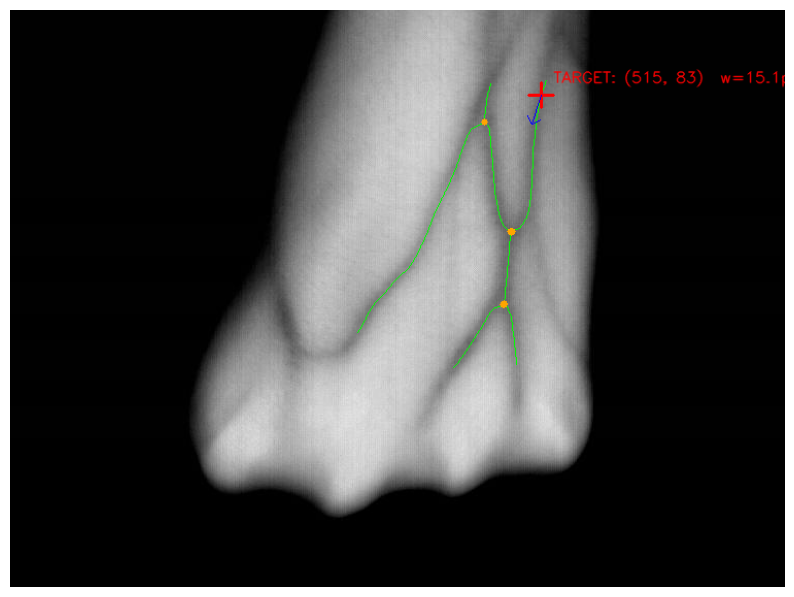

target=(515,83) width=15.1px  dist to nearest branch=61px  axis=[   -0.27532     0.96135]


In [79]:
from vein_postprocess import *
net = smp.Unet("resnet34", encoder_weights=None, in_channels=3, classes=1).to(device)
net.load_state_dict(torch.load("/kaggle/working/best_unet.pt", map_location=device)); net.eval()

@torch.no_grad()
def predict_prob(bgr):
    h, w = bgr.shape[:2]
    g = clahe.apply(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY))
    x = val_tf(image=cv2.cvtColor(g, cv2.COLOR_GRAY2RGB), mask=np.zeros((h, w), np.float32))["image"][None].to(device)
    p = torch.sigmoid(net(x)) + torch.sigmoid(net(x.flip(-1))).flip(-1)     # flip test-time augmentation
    return cv2.resize((p / 2)[0, 0].cpu().numpy(), (w, h))

def process(bgr, thr=0.5):
    prob = predict_prob(bgr)
    a = analyse(prob, thr=thr, min_area=80, spur_len=10, junction_pad=6)
    t = pick_target(a, min_len=25, min_width=4.0, safe_junction_px=15, end_margin=8)
    return a, t

import matplotlib.pyplot as plt
img = cv2.imread("/kaggle/input/datasets/minhaj099/testv1/person_001_db1_L2_png.rf.36956b13fa9afb6822fb94a5532e27c6.jpg")                             # <- change [test_img_path]
a, t = process(img)
plt.figure(figsize=(10, 8)); plt.imshow(draw(img, a, t)[..., ::-1]); plt.axis("off"); plt.show()
if t: print(f"target=({t.x},{t.y}) width={t.width_px:.1f}px  dist to nearest branch={t.dist_to_junction_px:.0f}px  axis={t.direction}")

## 7. Video (streams frame by frame, smooths the target so it does not jitter)

In [81]:
cap = cv2.VideoCapture("/kaggle/input/datasets/minhaj099/hand-vid-v4/hand_vid_v4.mp4")                     # <- change [test_vid_path]
W, H, FPS = int(cap.get(3)), int(cap.get(4)), cap.get(cv2.CAP_PROP_FPS) or 25
out = cv2.VideoWriter("/kaggle/working/vein_out.mp4", cv2.VideoWriter_fourcc(*"mp4v"), FPS, (W, H))
sm = TargetSmoother(alpha=0.3, jump_px=25)
while True:
    ok, frame = cap.read()
    if not ok: break
    a, t = process(frame)
    vis = draw(frame, a, None)
    p = sm.update(t)
    if p:
        cv2.drawMarker(vis, p, (0, 0, 255), cv2.MARKER_CROSS, 24, 2)
        cv2.putText(vis, f"TARGET: {p}", (p[0] + 12, p[1] - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
    out.write(vis)
cap.release(); out.release()

## 8. How to evaluate (report these, not just Dice)
* **Dice / clDice** on held-out *subjects*, separately for thin and thick veins.
* **Centreline error** (px, or mm using `px_per_mm` from a reference marker) against an expert-drawn centreline.
* **Target error** vs an expert-marked insertion point, and **hit rate** = % of frames where the target lies inside the vein (distance < width/2).
* **Stability** over video: std-dev of the target while the hand is still.